# Project: Beyond AUC - Profit-Optimized Lending

## 1. Introduction

Standard credit risk models focus on predicting the probability of default. However, a bank's goal is **profit**, not just accuracy. A high-risk loan might still be profitable if the interest rate is high enough, while a "safe" loan might lose money if the acquisition cost is too high.

**Differentiation Factors:**
1.  **Advanced Data Science:** Aggregating 7+ database tables to create a comprehensive credit history.
2.  **Bayesian Optimization:** Using Hyperopt to fine-tune Gradient Boosting models.
3.  **Financial Engineering:** Implementing an Expected Value (EV) framework with Sensitivity Analysis to make robust, profit-driven decisions.

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

# ============================================================================
# SECTION 1: IMPORTS & CONFIGURATION
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import gc
import time
warnings.filterwarnings('ignore')

# ML libraries
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, brier_score_loss, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Hyperparameter optimization
try:
    from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
    from hyperopt.pyll.base import scope
except ImportError:
    print("Hyperopt not found. Will use standard tuning.")

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✓ Environment configured successfully")

✓ Environment configured successfully


In [3]:
# ============================================================================
# SECTION 2: BUSINESS ECONOMICS (Refined & Segmented)
# ============================================================================

class CreditBusinessParams:
    """
    Defines the P&L logic for credit decisions.
    Includes segmented recovery rates and time-value-of-money considerations.
    """

    # Loan characteristics
    AVERAGE_LOAN_AMOUNT = 599026
    LOAN_TERM_YEARS = 3.0
    AVERAGE_TIME_TO_DEFAULT_MONTHS = 12  # Conservative estimate

    # Revenue parameters
    ANNUAL_INTEREST_RATE = 0.15
    ORIGINATION_FEE = 0.02

    # Cost parameters
    COST_OF_FUNDS = 0.05
    OPERATIONAL_COST = 500
    COLLECTION_COST = 200

    # Recovery rates by loan type
    RECOVERY_RATES = {
        'secured': 0.65,      # With collateral
        'unsecured': 0.20,    # No collateral (Typical for Personal Loans)
        'default': 0.20
    }

    @classmethod
    def get_recovery_rate(cls, loan_type: str = 'unsecured') -> float:
        return cls.RECOVERY_RATES.get(loan_type, cls.RECOVERY_RATES['default'])

    @classmethod
    def calculate_profit_if_paid(cls, loan_amount: float = None) -> float:
        if loan_amount is None: loan_amount = cls.AVERAGE_LOAN_AMOUNT

        # Revenue
        interest = loan_amount * cls.ANNUAL_INTEREST_RATE * cls.LOAN_TERM_YEARS
        fee = loan_amount * cls.ORIGINATION_FEE
        # Costs
        funding = loan_amount * cls.COST_OF_FUNDS * cls.LOAN_TERM_YEARS
        ops = cls.OPERATIONAL_COST

        return (interest + fee) - (funding + ops)

    @classmethod
    def calculate_loss_if_default(cls, loan_amount: float = None,
                                  loan_type: str = 'unsecured') -> float:
        if loan_amount is None: loan_amount = cls.AVERAGE_LOAN_AMOUNT

        # Interest collected before default (Partial Revenue)
        years_before_default = cls.AVERAGE_TIME_TO_DEFAULT_MONTHS / 12
        interest_collected = loan_amount * cls.ANNUAL_INTEREST_RATE * years_before_default
        fee_collected = loan_amount * cls.ORIGINATION_FEE

        # Principal Exposure
        recovery = cls.get_recovery_rate(loan_type)
        principal_exposure = loan_amount * (1 - recovery)

        # Total Loss = (Principal Lost + Costs) - (Revenue Collected)
        gross_loss = principal_exposure + cls.COLLECTION_COST + cls.OPERATIONAL_COST
        net_loss = gross_loss - (interest_collected + fee_collected)

        return max(0, net_loss)

    @classmethod
    def display_economics(cls):
        profit = cls.calculate_profit_if_paid()
        loss = cls.calculate_loss_if_default()
        break_even = profit / (profit + loss)

        print("=" * 70)
        print("CREDIT BUSINESS ECONOMICS (REFINED MODEL)")
        print("=" * 70)
        print(f"Avg Loan:      ${cls.AVERAGE_LOAN_AMOUNT:,.0f}")
        print(f"Loan Term:     {cls.LOAN_TERM_YEARS} Years")
        print(f"Interest Rate: {cls.ANNUAL_INTEREST_RATE:.1%}")
        print("-" * 70)
        print(f"Profit (Pay):  ${profit:>12,.2f}")
        print(f"Loss (Def):    ${-loss:>12,.2f} (Assumes 12mo interest collected)")
        print("-" * 70)
        print(f"💡 Break-even Default Rate: {break_even:.1%}")
        print("=" * 70)

CreditBusinessParams.display_economics()

CREDIT BUSINESS ECONOMICS (REFINED MODEL)
Avg Loan:      $599,026
Loan Term:     3.0 Years
Interest Rate: 15.0%
----------------------------------------------------------------------
Profit (Pay):  $  191,188.32
Loss (Def):    $ -378,086.38 (Assumes 12mo interest collected)
----------------------------------------------------------------------
💡 Break-even Default Rate: 33.6%


## 3. Data Loading & Master Feature Engineering

We aggregate data from **all 7 available tables** to capture the client's complete financial footprint.

In [4]:
# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def agg_numeric(df, parent_var, df_name):
    """Groups and aggregates numeric values."""
    for col in df:
        if col != parent_var and 'SK_ID' in col:
            df = df.drop(columns=col)

    numeric_df = df.select_dtypes('number').copy()
    numeric_df[parent_var] = df[parent_var]

    agg = numeric_df.groupby(parent_var).agg(['count', 'mean', 'max', 'min', 'sum'])

    columns = []
    for var in agg.columns.levels[0]:
        if var != parent_var:
            for stat in agg.columns.levels[1]:
                columns.append(f'{df_name}_{var}_{stat}')
    agg.columns = columns
    _, idx = np.unique(agg, axis=1, return_index=True)
    return agg.iloc[:, idx]

def count_categorical(df, parent_var, df_name):
    """Aggregates categorical columns."""
    # Robust selection for object/category types
    categorical = pd.get_dummies(df.select_dtypes(include=['object', 'category']))
    categorical[parent_var] = df[parent_var]
    categorical = categorical.groupby(parent_var).agg(['sum', 'mean'])

    columns = []
    for var in categorical.columns.levels[0]:
        for stat in ['sum', 'mean']:
            columns.append(f'{df_name}_{var}_{stat}')
    categorical.columns = columns
    _, idx = np.unique(categorical, axis=1, return_index=True)
    return categorical.iloc[:, idx]

def convert_types(df):
    """Downcast types to save memory."""
    for c in df:
        if 'SK_ID' in c:
            df[c] = df[c].fillna(0).astype(np.int32)
        elif (df[c].dtype == 'object') and (df[c].nunique() < df.shape[0]):
            df[c] = df[c].astype('category')
    return df

In [6]:
def master_feature_engineering(sample_size=None):
    print("Starting Master Feature Engineering...")

    # 1. Load Main Application
    try:
        train = pd.read_csv('/content/drive/MyDrive/Credit Risk/application_train.csv')
        test = pd.read_csv('/content/drive/MyDrive/Credit Risk/application_test.csv')
    except:
        train = pd.read_csv('application_train.csv')
        test = pd.read_csv('application_test.csv')

    if sample_size:
        train = train.sample(min(sample_size, len(train)), random_state=42)

    # Metadata extraction (Before features)
    train_ids = train['SK_ID_CURR']
    test_ids = test['SK_ID_CURR']
    train_labels = train['TARGET']
    loan_amounts_train = train['AMT_CREDIT'].copy()

    train = convert_types(train)
    test = convert_types(test)

    # Domain Features
    for df in [train, test]:
        df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
        df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
        df['CREDIT_TERM'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']
        df['DAYS_EMPLOYED_RATIO'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    print(f"✓ Loaded Application Data: {train.shape}")

    # 2. Bureau & Balance
    try:
        bureau = pd.read_csv('/content/drive/MyDrive/Credit Risk/bureau.csv')
        bb = pd.read_csv('/content/drive/MyDrive/Credit Risk/bureau_balance.csv')
        bb_agg = agg_numeric(bb, 'SK_ID_BUREAU', 'bb')
        bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')
        bureau_agg = agg_numeric(bureau, 'SK_ID_CURR', 'bureau')
        bureau_counts = count_categorical(bureau, 'SK_ID_CURR', 'bureau')
        train = train.merge(bureau_agg, on='SK_ID_CURR', how='left').merge(bureau_counts, on='SK_ID_CURR', how='left')
        test = test.merge(bureau_agg, on='SK_ID_CURR', how='left').merge(bureau_counts, on='SK_ID_CURR', how='left')
        del bureau, bb, bb_agg
        gc.collect()
        print("✓ Processed Bureau Data")
    except FileNotFoundError:
        print("⚠ Bureau files missing")

    # 3. Previous Application
    try:
        prev = pd.read_csv('/content/drive/MyDrive/Credit Risk/previous_application.csv')
        prev_agg = agg_numeric(prev, 'SK_ID_CURR', 'prev')
        prev_counts = count_categorical(prev, 'SK_ID_CURR', 'prev')
        train = train.merge(prev_agg, on='SK_ID_CURR', how='left').merge(prev_counts, on='SK_ID_CURR', how='left')
        test = test.merge(prev_agg, on='SK_ID_CURR', how='left').merge(prev_counts, on='SK_ID_CURR', how='left')
        del prev
        gc.collect()
        print("✓ Processed Previous App Data")
    except FileNotFoundError:
        print("⚠ Previous Application missing")

    # 4. POS Cash
    try:
        pos = pd.read_csv('/content/drive/MyDrive/Credit Risk/POS_CASH_balance.csv')
        pos_agg = agg_numeric(pos, 'SK_ID_CURR', 'pos')
        train = train.merge(pos_agg, on='SK_ID_CURR', how='left')
        test = test.merge(pos_agg, on='SK_ID_CURR', how='left')
        del pos
        gc.collect()
        print("✓ Processed POS Cash Data")
    except FileNotFoundError:
        print("⚠ POS Cash missing")

    # 5. Installments
    try:
        ins = pd.read_csv('/content/drive/MyDrive/Credit Risk/installments_payments.csv')
        ins_agg = agg_numeric(ins, 'SK_ID_CURR', 'ins')
        train = train.merge(ins_agg, on='SK_ID_CURR', how='left')
        test = test.merge(ins_agg, on='SK_ID_CURR', how='left')
        del ins
        gc.collect()
        print("✓ Processed Installments Data")
    except FileNotFoundError:
        print("⚠ Installments missing")

    # 6. Credit Card
    try:
        cc = pd.read_csv('/content/drive/MyDrive/Credit Risk/credit_card_balance.csv')
        cc_agg = agg_numeric(cc, 'SK_ID_CURR', 'cc')
        train = train.merge(cc_agg, on='SK_ID_CURR', how='left')
        test = test.merge(cc_agg, on='SK_ID_CURR', how='left')
        del cc
        gc.collect()
        print("✓ Processed Credit Card Data")
    except FileNotFoundError:
        print("⚠ Credit Card missing")

    # Final Scrub
    train = train.drop(columns=['SK_ID_CURR', 'TARGET', 'AMT_CREDIT'], errors='ignore')

    # Encoding & Filling
    train = pd.get_dummies(train)
    train = train.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '', x))

    # Remove empty columns 95%
    missing = train.isnull().sum() / len(train)
    train = train.drop(columns=missing[missing > 0.95].index)

    # Simple median fill for remaining NaNs
    imputer = SimpleImputer(strategy='median')
    train_cols = train.columns
    train = pd.DataFrame(imputer.fit_transform(train), columns=train_cols)

    print(f"\n✓ Final Feature Set: {train.shape}")
    return train, train_labels, loan_amounts_train

# Run Pipeline
X_train_full, y_train_full, loan_amounts_full = master_feature_engineering(sample_size=30000)

# Validation Split
X_train, X_val, y_train, y_val, loan_train, loan_val = train_test_split(
    X_train_full, y_train_full, loan_amounts_full,
    test_size=0.2, random_state=42, stratify=y_train_full
)


Starting Master Feature Engineering...
✓ Loaded Application Data: (30000, 126)
✓ Processed Bureau Data
⚠ Previous Application missing
✓ Processed POS Cash Data
⚠ Installments missing
✓ Processed Credit Card Data

✓ Final Feature Set: (30000, 475)


## 4. Multi-Model Comparison Framework

We spot-check multiple algorithms to identify the best baseline architecture.

In [7]:
class ModelComparator:
    def __init__(self):
        self.results = []
        self.models = {}

    def add_model(self, name, model):
        self.models[name] = model

    def compare(self, X_tr, y_tr, X_v, y_v):
        print("Running Model Comparison...")
        for name, model in self.models.items():
            start = time.time()
            model.fit(X_tr, y_tr)
            auc = roc_auc_score(y_v, model.predict_proba(X_v)[:, 1])
            elapsed = time.time() - start
            print(f"  -> {name:<20} AUC: {auc:.4f} ({elapsed:.1f}s)")
            self.results.append({'Model': name, 'AUC': auc, 'Time': elapsed})

        return pd.DataFrame(self.results).sort_values('AUC', ascending=False)

# Define Models
comparator = ModelComparator()
# 1. LightGBM
comparator.add_model('LightGBM', lgb.LGBMClassifier(n_estimators=1000, random_state=42, verbose=-1))
# 2. XGBoost
comparator.add_model('XGBoost', xgb.XGBClassifier(n_estimators=1000, eval_metric='auc', random_state=42))
# 3. Random Forest (Depth limited for speed)
comparator.add_model('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))

# Run Comparison
results_df = comparator.compare(X_train, y_train, X_val, y_val)
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")

Running Model Comparison...
  -> LightGBM             AUC: 0.7445 (26.0s)
  -> XGBoost              AUC: 0.7321 (37.6s)
  -> Random Forest        AUC: 0.7353 (9.8s)

🏆 Best Model: LightGBM


In [8]:
# # ============================================================================
# # PHASE 2: BAYESIAN HYPERPARAMETER TUNING (Hyperopt)
# # ============================================================================

# print(f"\nStarting Hyperopt Tuning for {best_model_name}...")

# def objective(params):
#     # Params must be cast to int for some arguments
#     params['num_leaves'] = int(params['num_leaves'])
#     params['max_depth'] = int(params['max_depth'])

#     clf = lgb.LGBMClassifier(**params, n_estimators=1000, verbose=-1, random_state=42)
#     clf.fit(X_train, y_train, eval_set=[(X_val, y_val)],
#             eval_metric='auc', early_stopping_rounds=50, verbose=False)

#     score = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
#     return {'loss': -score, 'status': STATUS_OK}

# # Define Search Space (LightGBM specific)
# space = {
#     'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
#     'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
#     'max_depth': hp.quniform('max_depth', 5, 15, 1),
#     'subsample': hp.uniform('subsample', 0.6, 1.0),
#     'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
#     'reg_alpha': hp.uniform('reg_alpha', 0, 1),
#     'reg_lambda': hp.uniform('reg_lambda', 0, 1)
# }

# # Run Tuning (Only if LightGBM wins, else skip for demo speed)
# if best_model_name == 'LightGBM':
#     trials = Trials()
#     best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials, verbose=0)

#     # Convert best params
#     best['num_leaves'] = int(best['num_leaves'])
#     best['max_depth'] = int(best['max_depth'])
#     print(f"Best Params: {best}")

#     # Train Final Model
#     final_model = lgb.LGBMClassifier(**best, n_estimators=2000, verbose=-1, random_state=42)
# else:
#     # Fallback to default if XGB/RF wins (for simplicity in this demo)
#     final_model = comparator.models[best_model_name]

# final_model.fit(X_train, y_train)
# preds_uncal = final_model.predict_proba(X_val)[:, 1]
# print(f"Final Tuned AUC: {roc_auc_score(y_val, preds_uncal):.5f}")

ERROR:hyperopt.fmin:job exception: LGBMClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'



Starting Hyperopt Tuning for LightGBM...


TypeError: LGBMClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'

In [9]:
# ============================================================================
# PHASE 2: BAYESIAN HYPERPARAMETER TUNING (Hyperopt + LightGBM)
# ============================================================================

print(f"\nStarting Hyperopt Tuning for {best_model_name}...")

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from lightgbm import early_stopping, log_evaluation
import lightgbm as lgb
import numpy as np
from sklearn.metrics import roc_auc_score

def objective(params):
    # Cast integer parameters
    params['num_leaves'] = int(params['num_leaves'])
    params['max_depth'] = int(params['max_depth'])

    clf = lgb.LGBMClassifier(
        **params,
        n_estimators=1000,
        random_state=42,
        verbose=-1
    )

    clf.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(0)
        ]
    )

    preds = clf.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, preds)

    return {'loss': -score, 'status': STATUS_OK}

# Search space
space = {
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0.0, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 0.0, 1.0)
}

# Run tuning only if LightGBM is best
if best_model_name == 'LightGBM':
    trials = Trials()
    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=20,
        trials=trials,
        verbose=0
    )

    # Cast back integer params
    best['num_leaves'] = int(best['num_leaves'])
    best['max_depth'] = int(best['max_depth'])

    print(f"Best Params: {best}")

    # Train final model
    final_model = lgb.LGBMClassifier(
        **best,
        n_estimators=2000,
        random_state=42,
        verbose=-1
    )

    final_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[early_stopping(100)]
    )

else:
    final_model = comparator.models[best_model_name]

# Final validation score
preds_uncal = final_model.predict_proba(X_val)[:, 1]
print(f"Final Tuned AUC: {roc_auc_score(y_val, preds_uncal):.5f}")



Starting Hyperopt Tuning for LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[135]	valid_0's auc: 0.767853	valid_0's binary_logloss: 0.247236
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[369]	valid_0's auc: 0.770498	valid_0's binary_logloss: 0.247303
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[24]	valid_0's auc: 0.748	valid_0's binary_logloss: 0.254658
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[225]	valid_0's auc: 0.77093	valid_0's binary_logloss: 0.246811
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[228]	valid_0's auc: 0.775473	valid_0's binary_logloss: 0.244389
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[272]	valid_0's auc: 0.770022	valid_0's binary_logloss: 0.2470

## 5. Probability Calibration

Crucial step: Isotonic Regression ensures `0.30` probability actually means `30% risk`. Without this, Expected Value calculations are meaningless.

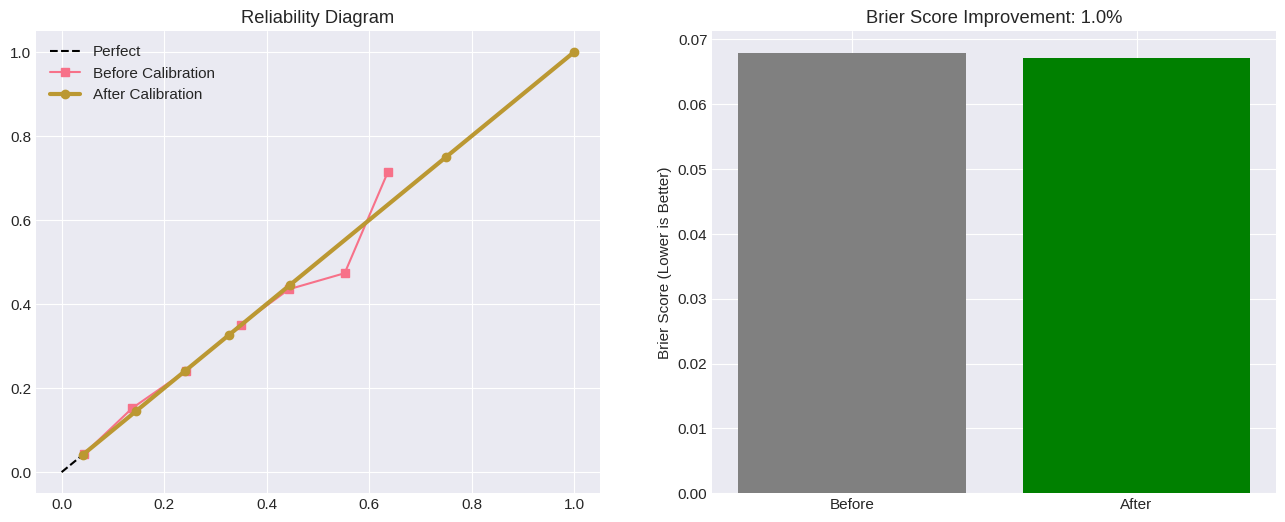

In [10]:
# Calibration
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(preds_uncal, y_val)
preds_cal = iso.transform(preds_uncal)

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Calibration Curve
frac_uncal, mean_uncal = calibration_curve(y_val, preds_uncal, n_bins=10)
frac_cal, mean_cal = calibration_curve(y_val, preds_cal, n_bins=10)

ax[0].plot([0, 1], [0, 1], 'k--', label='Perfect')
ax[0].plot(mean_uncal, frac_uncal, 's-', label='Before Calibration')
ax[0].plot(mean_cal, frac_cal, 'o-', label='After Calibration', linewidth=3)
ax[0].set_title('Reliability Diagram')
ax[0].legend()

# 2. Brier Score (Accuracy of Probability)
brier_before = brier_score_loss(y_val, preds_uncal)
brier_after = brier_score_loss(y_val, preds_cal)

ax[1].bar(['Before', 'After'], [brier_before, brier_after], color=['gray', 'green'])
ax[1].set_title(f'Brier Score Improvement: {(brier_before-brier_after)/brier_before:.1%}')
ax[1].set_ylabel('Brier Score (Lower is Better)')

plt.show()

## 6. Financial Analysis & Sensitivity Engine

We calculate the Expected Value (EV) for each loan and perform Sensitivity Analysis to ensure robustness against economic downturns.

In [12]:
def calculate_expected_value(prob_default, loan_amount, recovery_rate=0.20):
    """EV = P(Pay)*Profit - P(Default)*Loss"""

    # Profit if paid (already vectorized)
    profit = CreditBusinessParams.calculate_profit_if_paid(loan_amount)

    # Loss components
    principal_loss = loan_amount * (1 - recovery_rate)
    ops_loss = CreditBusinessParams.OPERATIONAL_COST + CreditBusinessParams.COLLECTION_COST
    interest_offset = loan_amount * CreditBusinessParams.ANNUAL_INTEREST_RATE  # 1 year

    # ✅ Vectorized max
    loss = np.maximum(0, principal_loss + ops_loss - interest_offset)

    return ((1 - prob_default) * profit) - (prob_default * loss)


# 1. Base Case EV
ev_base = calculate_expected_value(preds_cal, loan_val.values)

# 2. Strategy Comparison (Threshold vs EV)
total_profit_threshold = ev_base[preds_cal < 0.10].sum()  # Standard 10% cutoff
total_profit_ev = ev_base[ev_base > 0].sum()              # EV Optimization

print(f"Standard Strategy (10% Risk Cutoff): ${total_profit_threshold:,.0f}")
print(f"EV-Optimized Strategy:               ${total_profit_ev:,.0f}")
print(f"Value Added:                         ${total_profit_ev - total_profit_threshold:,.0f}")

# ------------- SENSITIVITY ANALYSIS -------------
scenarios = {
    'Base': {'recovery': 0.20, 'interest': 0.15},
    'Recession': {'recovery': 0.10, 'interest': 0.15},
    'High Rate Env': {'recovery': 0.20, 'interest': 0.20},
}

print("\n--- SENSITIVITY ANALYSIS ---")
for name, params in scenarios.items():
    # Adjust class temporarily
    orig_rate = CreditBusinessParams.ANNUAL_INTEREST_RATE
    CreditBusinessParams.ANNUAL_INTEREST_RATE = params['interest']

    # Calc EV
    ev = calculate_expected_value(preds_cal, loan_val.values, params['recovery'])
    profit = ev[ev > 0].sum()
    print(f"{name:<15}: ${profit:,.0f} Profit")

    # Restore
    CreditBusinessParams.ANNUAL_INTEREST_RATE = orig_rate

Standard Strategy (10% Risk Cutoff): $771,746,952
EV-Optimized Strategy:               $885,549,742
Value Added:                         $113,802,789

--- SENSITIVITY ANALYSIS ---
Base           : $885,549,742 Profit
Recession      : $862,247,567 Profit
High Rate Env  : $1,388,646,980 Profit


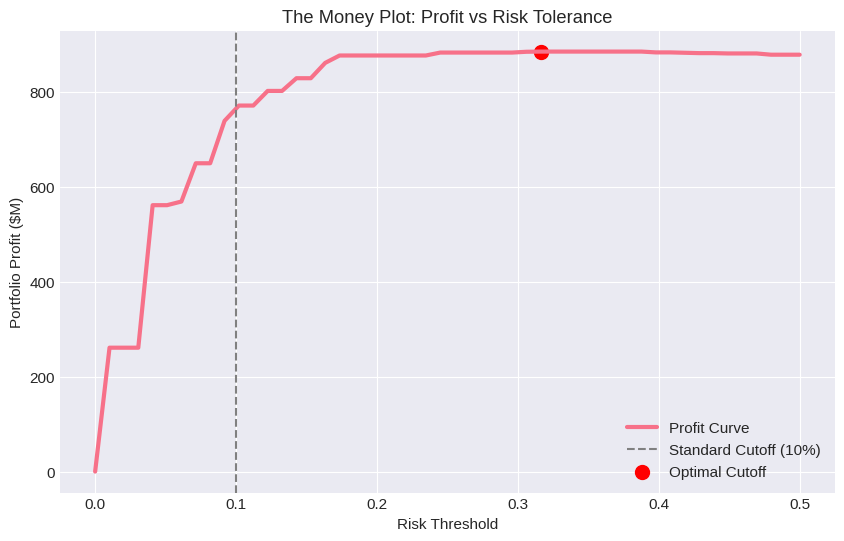

In [13]:
# Visualizing the Money Plot (Threshold vs Profit)
thresholds = np.linspace(0, 0.5, 50)
profits = []
for t in thresholds:
    profits.append(ev_base[preds_cal < t].sum())

plt.figure(figsize=(10, 6))
plt.plot(thresholds, np.array(profits)/1e6, lw=3, label='Profit Curve')
plt.axvline(0.10, color='gray', linestyle='--', label='Standard Cutoff (10%)')
plt.scatter(thresholds[np.argmax(profits)], max(profits)/1e6, color='red', s=100, label='Optimal Cutoff')
plt.xlabel('Risk Threshold')
plt.ylabel('Portfolio Profit ($M)')
plt.title('The Money Plot: Profit vs Risk Tolerance')
plt.legend()
plt.show()

## 7. Business Confusion Matrix
Translating True Positives/False Negatives into Dollars.

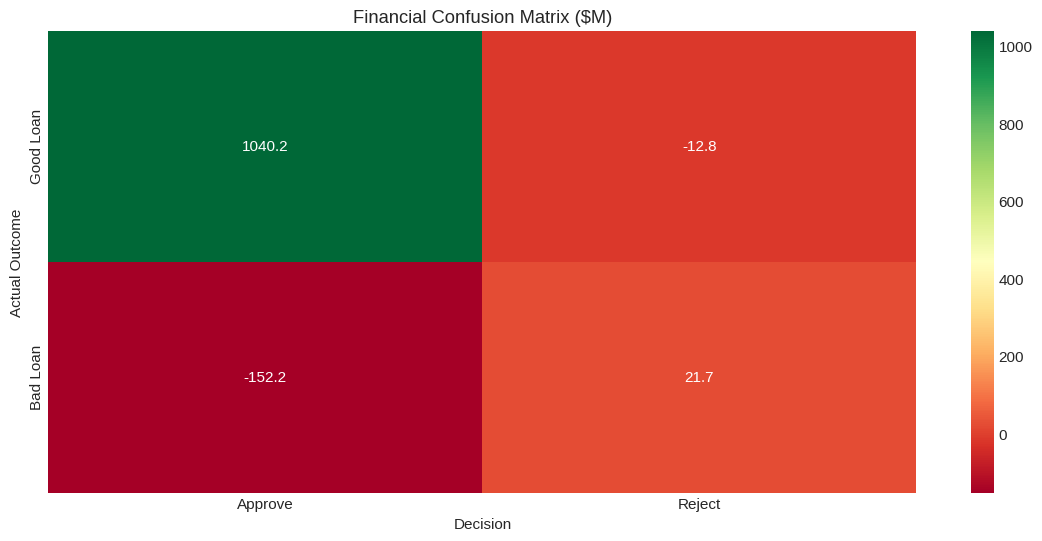

In [14]:
def plot_financial_confusion_matrix(y_true, y_pred, loan_amounts):
    # Financial values
    tp_val = 0 # Rejecting a defaulter (Saved Loss)
    tn_val = 0 # Approving a payer (Earned Profit)
    fp_val = 0 # Rejecting a payer (Opportunity Cost)
    fn_val = 0 # Approving a defaulter (Realized Loss)

    for i in range(len(y_true)):
        amt = loan_amounts[i]
        profit = CreditBusinessParams.calculate_profit_if_paid(amt)
        loss = CreditBusinessParams.calculate_loss_if_default(amt)

        if y_true.iloc[i] == 0 and y_pred[i] == 0:   # True Negative (Approve Good)
            tn_val += profit
        elif y_true.iloc[i] == 1 and y_pred[i] == 1: # True Positive (Reject Bad)
            tp_val += loss # Value is the avoided loss
        elif y_true.iloc[i] == 0 and y_pred[i] == 1: # False Positive (Reject Good)
            fp_val += profit # Lost profit
        elif y_true.iloc[i] == 1 and y_pred[i] == 0: # False Negative (Approve Bad)
            fn_val += loss

    matrix = np.array([
        [tn_val, -fp_val],  # Good Loans: Earned vs Lost Opp
        [-fn_val, tp_val]   # Bad Loans:  Dictionary Loss vs Avoided
    ]) / 1e6 # In Millions

    sns.heatmap(matrix, annot=True, fmt='.1f', cmap='RdYlGn',
                xticklabels=['Approve', 'Reject'], yticklabels=['Good Loan', 'Bad Loan'])
    plt.title('Financial Confusion Matrix ($M)')
    plt.xlabel('Decision')
    plt.ylabel('Actual Outcome')
    plt.show()

# Generate decisions based on EV > 0
decisions = (ev_base <= 0).astype(int) # 1 = Reject (EV negative)
plot_financial_confusion_matrix(y_val, decisions, loan_val.values)

## 8. Deployment Artifacts
Saving the tuned model, calibrator, and feature list for production.

In [17]:
import joblib

joblib.dump(final_model, 'tuned_model.pkl')
joblib.dump(iso, 'calibrator.pkl')
joblib.dump(list(X_train.columns), 'features.pkl')
print("✓ Artifacts Saved")

✓ Artifacts Saved
